In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
import os
import cv2
import numpy as np
import pandas as pd

drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/dental_dataset/dental_dataset'
images_folder = os.path.join(dataset_path, "images", "train")
# images_folder = os.path.join(dataset_path, "images", "valid")

output_csv = os.path.join(dataset_path, "manual_features_train2.csv")

if not os.path.exists(images_folder):
    raise FileNotFoundError(f"Image folder not found: {images_folder}")


image_files = [f for f in os.listdir(images_folder) if f.lower().endswith((".jpg", ".png"))]
print(f"Number of images found: {len(image_files)}")

def extract_manual_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    features = {}
    features["mean_intensity"] = float(np.mean(img))

    features["std_intensity"] = float(np.std(img))

    dark_pixels = np.sum(img < np.percentile(img, 5))
    features["dark_pixel_count"] = int(dark_pixels)

    left_half = img[:, :img.shape[1] // 2]
    right_half = img[:, img.shape[1] // 2:]
    symmetry_score = abs(np.mean(left_half) - np.mean(right_half))
    features["symmetry_score"] = float(symmetry_score)

    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-8))
    features["image_entropy"] = float(entropy)

    return features

features_list = []

for i, img_file in enumerate(image_files):
    print(f"[{i+1}/{len(image_files)}] Processing: {img_file}")
    try:
        img_path = os.path.join(images_folder, img_file)
        features = extract_manual_features(img_path)
        features["image_name"] = img_file
        features_list.append(features)
    except Exception as e:
        print(f"Error processing {img_file}: {str(e)}")
        continue

df = pd.DataFrame(features_list)
df.to_csv(output_csv, index=False)

print(f"\nFeatures saved to: {output_csv}")
print("First 5 rows:")
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of images found: 2871
[1/2871] Processing: 4066680000-jpg_png_jpg.rf.6451cc4f90887ed6f073de71ff8e3eb1.jpg
[2/2871] Processing: 4066680000-jpg_png_jpg.rf.bb43289ee2e415a43f8ed2c7344be1cd.jpg
[3/2871] Processing: 4066870000-jpg_png_jpg.rf.f4de549d54ac8190167da0ff54317d08.jpg
[4/2871] Processing: 4067600000-jpg_png_jpg.rf.6599fb9629ccb11f404a2800df54cd64.jpg
[5/2871] Processing: 4067600000-jpg_png_jpg.rf.9f46e7fe7e303a54b9014d14da83422b.jpg
[6/2871] Processing: 4068250000-jpg_png_jpg.rf.6212b5f121df626658c0980ce231c225.jpg
[7/2871] Processing: 4068530000-jpg_png_jpg.rf.a96f4733d190df1061e0e1e35a19b4a3.jpg
[8/2871] Processing: 4068540000-jpg_png_jpg.rf.594a9aefa49e696a19238187ea3b4ecf.jpg
[9/2871] Processing: 4068540000-jpg_png_jpg.rf.de1766ccd853f0557fd2d77f14a39362.jpg
[10/2871] Processing: 4069100000-jpg_png_jpg.rf.35bf35ed7c6c16e7df23c79dca03fad5.jpg
[

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dental_dataset/dental_dataset/manual_features_train2.csv")
print(" عدد الصفوف:", len(df))
print(df.head(10))
print(" الأعمدة الموجودة:")
print(df.columns.tolist())

 عدد الصفوف: 9443
   mean_intensity  std_intensity  dark_pixel_count  symmetry_score  \
0       88.844697      53.557402                 0        4.106357   
1      105.238589      60.210632                 0        3.483545   
2       98.488962      57.865843                 0        3.496548   
3       96.828770      56.193228                 0        2.329219   
4       75.586833      49.533948                 0        2.316040   
5      111.527019      62.701976                 0        6.282476   
6      143.643188      60.962198              2380        6.198076   
7      109.689028      63.888676                 0        2.578789   
8      124.294851      63.221685              7102        2.592622   
9       96.858447      58.513415                 0        1.871172   

   image_entropy                                         image_name  
0       6.825686  cropped_ARJAN-SINGH_2023-10-21114049_1_png.rf....  
1       6.740990  cropped_ARMINDER-SINGH_2023-10-21151030_1_png....  
2

In [ ]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

class CNNFeatureExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.feature_extractor = torch.nn.Sequential(*list(self.model.children())[:-1])

    def forward(self, x):
        with torch.no_grad():
            features = self.feature_extractor(x).flatten(start_dim=1)
        return features

In [ ]:
import os
images_folder = "/content/drive/MyDrive/dental_dataset/dental_dataset/images/train"
output_csv = "/content/drive/MyDrive/dental_dataset/dental_dataset/cnn_features_train.csv"

os.makedirs(os.path.dirname(output_csv), exist_ok=True)

In [ ]:
from torchvision.io import read_image
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
cnn_extractor = CNNFeatureExtractor()
cnn_extractor.eval()

image_files = [f for f in os.listdir(images_folder) if f.lower().endswith((".jpg", ".png"))]
features_list = []

for i, img_file in enumerate(image_files):
    print(f"Extracting features from image {i+1}/{len(image_files)}: {img_file}")

    try:
        img_path = os.path.join(images_folder, img_file)
        img = read_image(img_path)
        img = transform(img).unsqueeze(0)  # Shape: [1, 3, 224, 224]

        with torch.no_grad():
            cnn_features = cnn_extractor(img).squeeze(0).cpu().numpy()  # Shape: [2048]

        features_list.append({
            "image_name": img_file,
            **{f"cnn_{j}": cnn_features[j] for j in range(cnn_features.shape[0])}
        })

    except Exception as e:
        print(f"Error processing {img_file}: {str(e)}")
        continue

df_cnn = pd.DataFrame(features_list)
df_cnn.to_csv(output_csv, index=False)

print(f"CNN features saved to: {output_csv}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 103MB/s]


Extracting features from image 1/9443: cropped_ARJAN-SINGH_2023-10-21114049_1_png.rf.b69da0570af4e1412f3db4930530b05e.jpg


/usr/local/lib/python3.11/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Extracting features from image 4444/9443: 3975470000-jpg_png_jpg.rf.39e54ff36fa9d84b2511649d72549353.jpg
Extracting features from image 4445/9443: 3975470000-jpg_png_jpg.rf.74efec0eebc1fa19b250b1b6d622e1f0.jpg
Extracting features from image 4446/9443: 3975470000-jpg_png_jpg.rf.ead21d51a77dc6fa2ca200eda907fcc1.jpg
Extracting features from image 4447/9443: 3975520000-jpg_png_jpg.rf.6e4fda94da07ac0b60814bb6800c5d21.jpg
Extracting features from image 4448/9443: 3975520000-jpg_png_jpg.rf.8a9facf3c4c69fe5f05f7a6079b6e31d.jpg
Extracting features from image 4449/9443: 3975520000-jpg_png_jpg.rf.ba16dd8d454b141b57f1a939fa0956c2.jpg
Extracting features from image 4450/9443: 3975720000-jpg_png_jpg.rf.33dc4d3cb37a037be1c4a4ec7cc01466.jpg
Extracting features from image 4451/9443: 3975720000-jpg_png_jpg.rf.4e454c9c8614ac7bf9fb2e6be4eacabe.jpg
Extracting features from image 4452/9443: 3975720000-jpg_png_jpg.rf.efaded0394aed816cd0ebe6387521ee2.jpg
Extr

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd


if len(features_list) > 0:
    df_cnn = pd.DataFrame(features_list)
    df_cnn.to_csv(output_csv, index=False)
    print(f"Features saved to: {output_csv}")
else:
    print("No data to save.")


Features saved to: /content/drive/MyDrive/dental_dataset/dental_dataset/cnn_features_train.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dental_dataset/dental_dataset/cnn_features_train.csv")
print(" عدد الصفوف:", len(df))
print(df.head(10))
print(" الأعمدة الموجودة:")
print(df.columns.tolist())

 عدد الصفوف: 9443
                                          image_name     cnn_0     cnn_1  \
0  cropped_ARJAN-SINGH_2023-10-21114049_1_png.rf....  0.031355  0.619478   
1  cropped_ARMINDER-SINGH_2023-10-21151030_1_png....  0.032178  0.493335   
2  cropped_ARMINDER-SINGH_2023-10-21151030_1_png....  0.034500  0.426229   
3  cropped_ARSHDEEP-SINGH_2023-10-21124811_1_png....  0.042977  0.253108   
4  cropped_ARSHDEEP-SINGH_2023-10-21124811_1_png....  0.057880  0.300909   
5  cropped_ARTI-_2023-10-26181337_1_png.rf.a9a5f0...  0.109148  0.778551   
6  cropped_ARTI-_2023-10-26181337_1_png.rf.b733f6...  0.148565  0.919087   
7  cropped_Arun-Bansal_2023-10-26155146_1_png.rf....  0.140749  0.904578   
8  cropped_Arun-Bansal_2023-10-26155146_1_png.rf....  0.142311  0.834245   
9  cropped_ARVIND-SINGH_2023-10-21135329_1_png.rf...  0.097737  1.409632   

      cnn_2     cnn_3     cnn_4     cnn_5     cnn_6     cnn_7     cnn_8  ...  \
0  0.040540  0.084724  0.599837  0.366325  0.540656  0.319573  0.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dental_dataset/combined_features.csv")
print(" عدد الصفوف:", len(df))
print(df.head(10))
print(" الأعمدة الموجودة:")
print(df.columns.tolist())

 عدد الصفوف: 9443
                                          image_name     cnn_0     cnn_1  \
0  cropped_ARJAN-SINGH_2023-10-21114049_1_png.rf....  0.031355  0.619478   
1  cropped_ARMINDER-SINGH_2023-10-21151030_1_png....  0.032178  0.493335   
2  cropped_ARMINDER-SINGH_2023-10-21151030_1_png....  0.034500  0.426229   
3  cropped_ARSHDEEP-SINGH_2023-10-21124811_1_png....  0.042977  0.253108   
4  cropped_ARSHDEEP-SINGH_2023-10-21124811_1_png....  0.057880  0.300909   
5  cropped_ARTI-_2023-10-26181337_1_png.rf.a9a5f0...  0.109148  0.778551   
6  cropped_ARTI-_2023-10-26181337_1_png.rf.b733f6...  0.148565  0.919087   
7  cropped_Arun-Bansal_2023-10-26155146_1_png.rf....  0.140749  0.904578   
8  cropped_Arun-Bansal_2023-10-26155146_1_png.rf....  0.142311  0.834245   
9  cropped_ARVIND-SINGH_2023-10-21135329_1_png.rf...  0.097737  1.409632   

      cnn_2     cnn_3     cnn_4     cnn_5     cnn_6     cnn_7     cnn_8  ...  \
0  0.040540  0.084724  0.599837  0.366325  0.540656  0.319573  0.

In [ ]:
import json
import pandas as pd

json_path = "/content/drive/MyDrive/dental_dataset/dental_dataset/annotations/train_coco.json"
with open(json_path, 'r') as f:
    data = json.load(f)

category_to_name = {category['id']: category['name'] for category in data['categories']}
category_ids = sorted(category_to_name.keys())

class_names = [category_to_name[cid] for cid in category_ids]

num_classes = len(class_names)

category_to_index = {cid: idx for idx, cid in enumerate(category_ids)}

images_data = []
for image in data['images']:
    image_id = image['id']
    file_name = image['file_name']

    label_vector = [0] * num_classes

    for ann in data['annotations']:
        if ann['image_id'] == image_id:
            category_id = ann['category_id']
            class_index = category_to_index[category_id]
            label_vector[class_index] = 1

    image_entry = {'image_name': file_name}
    image_entry.update({class_names[i]: label_vector[i] for i in range(num_classes)})
    images_data.append(image_entry)

df_labels = pd.DataFrame(images_data)
df_labels.columns = df_labels.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
df_labels.to_csv('/content/drive/MyDrive/dental_dataset/image_labels.csv', index=False)



In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dental_dataset/image_labels.csv")
print(" عدد الصفوف:", len(df))
print(df.head(10))
print(" الأعمدة الموجودة:")
print(df.columns.tolist())

 عدد الصفوف: 9481
                                          image_name  Caries  Crown  Filling  \
0  000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-121853...       1      1        1   
1  000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-121853...       1      1        1   
2  003e5f80-MOHAMADI_ATEFEH_2020-06-01173808_jpg....       1      1        1   
3  0043783e-Asiadar_Leila_2022-06-12141026_jpg.rf...       1      1        1   
4  00cf39c1-Karaptiyan_Robert_50yo_13032021_18590...       0      1        1   
5  00cf39c1-Karaptiyan_Robert_50yo_13032021_18590...       0      1        1   
6  00cf39c1-Karaptiyan_Robert_50yo_13032021_18590...       0      1        1   
7  00cf39c1-Karaptiyan_Robert_50yo_13032021_18590...       0      1        1   
8  01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.r...       0      0        1   
9  01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.r...       0      0        1   

   Implant  Malaligned  Mandibular_Canal  Missing_teeth  Periapical_lesion  \
0        0           0 

In [ ]:
import pandas as pd

features_path = "/content/drive/MyDrive/dental_dataset/combined_features.csv"
df_features = pd.read_csv(features_path)

labels_path = "/content/drive/MyDrive/dental_dataset/image_labels.csv"
df_labels = pd.read_csv(labels_path)

df_labels.columns = df_labels.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')

df_features['image_name'] = df_features['image_name'].str.strip()
df_labels['image_name'] = df_labels['image_name'].str.strip()

df_features['image_name'] = df_features['image_name'].str.replace('.png', '', regex=False)
df_labels['image_name'] = df_labels['image_name'].str.replace('.png', '', regex=False)

df_combined = pd.merge(df_features, df_labels, on='image_name', how='inner')

output_path = "/content/drive/MyDrive/dental_dataset/dental_dataset/final_combined_dataset.csv"
df_combined.to_csv(output_path, index=False)

print(f"Merged successfully! Saved to: {output_path}")
print(f"Rows in final dataset: {df_combined.shape[0]}")
print(f"Columns in final dataset: {df_combined.shape[1]}")


Merged successfully! Saved to: /content/drive/MyDrive/dental_dataset/dental_dataset/final_combined_dataset.csv
Rows in final dataset: 9443
Columns in final dataset: 2085


In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_csv("/content/drive/MyDrive/dental_dataset/dental_dataset/final_combined_dataset.csv")

print("عدد الصفوف:", len(df))
print("الأعمدة الموجودة:")
print(df.columns.tolist())
print("\nأول 10 صفوف:")
print(df.head(10))


عدد الصفوف: 9443
الأعمدة الموجودة:
['image_name', 'cnn_0', 'cnn_1', 'cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'cnn_7', 'cnn_8', 'cnn_9', 'cnn_10', 'cnn_11', 'cnn_12', 'cnn_13', 'cnn_14', 'cnn_15', 'cnn_16', 'cnn_17', 'cnn_18', 'cnn_19', 'cnn_20', 'cnn_21', 'cnn_22', 'cnn_23', 'cnn_24', 'cnn_25', 'cnn_26', 'cnn_27', 'cnn_28', 'cnn_29', 'cnn_30', 'cnn_31', 'cnn_32', 'cnn_33', 'cnn_34', 'cnn_35', 'cnn_36', 'cnn_37', 'cnn_38', 'cnn_39', 'cnn_40', 'cnn_41', 'cnn_42', 'cnn_43', 'cnn_44', 'cnn_45', 'cnn_46', 'cnn_47', 'cnn_48', 'cnn_49', 'cnn_50', 'cnn_51', 'cnn_52', 'cnn_53', 'cnn_54', 'cnn_55', 'cnn_56', 'cnn_57', 'cnn_58', 'cnn_59', 'cnn_60', 'cnn_61', 'cnn_62', 'cnn_63', 'cnn_64', 'cnn_65', 'cnn_66', 'cnn_67', 'cnn_68', 'cnn_69', 'cnn_70', 'cnn_71', 'cnn_72', 'cnn_73', 'cnn_74', 'cnn_75', 'cnn_76', 'cnn_77', 'cnn_78', 'cnn_79', 'cnn_80', 'cnn_81', 'cnn_82', 'cnn_83', 'cnn_84', 'cnn_85', 'cnn_86', 'cnn_87', 'cnn_88', 'cnn_89', 'cnn_90', 'cnn_91', 'cnn_92', 'cnn_93', 'cnn_94', 'cnn_95', 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os


# csv_path = "/content/drive/MyDrive/dental_dataset/dental_dataset/final_combined_dataset.csv"
csv_path = "/content/drive/MyDrive/dental_dataset/dental_dataset/final_combined_dataset_valid.csv"
print(" Loading data from CSV...")
df = pd.read_csv(csv_path)


cnn_cols = [col for col in df.columns if col.startswith('cnn_')]
manual_cols = ['mean_intensity', 'std_intensity', 'dark_pixel_count', 'symmetry_score', 'image_entropy']
label_cols = [
    'Caries', 'Crown', 'Filling', 'Implant', 'Malaligned',
    'Mandibular_Canal', 'Missing_teeth', 'Periapical_lesion',
    'Retained_root', 'Root_Canal_Treatment', 'Root_Piece',
    'impacted_tooth', 'maxillary_sinus', 'Bone_Loss', 'Fracture_teeth',
    'Permanent_Teeth', 'Supra_Eruption', 'TAD', 'abutment', 'attrition',
    'bone_defect', 'gingival_former', 'metal_band', 'orthodontic_brackets',
    'permanent_retainer', 'post___core', 'plating', 'wire', 'Cyst',
    'Root_resorption', 'Primary_teeth'
]


X_cnn = df[cnn_cols].values.astype(np.float32)
X_manual = df[manual_cols].values.astype(np.float32)
y_labels = df[label_cols].values.astype(np.float32)

non_zero_rows = y_labels.sum(axis=1) > 0
X_cnn_cleaned = X_cnn[non_zero_rows]
X_manual_cleaned = X_manual[non_zero_rows]
y_cleaned = y_labels[non_zero_rows]

scaler_pca = StandardScaler()
X_cnn_scaled = scaler_pca.fit_transform(X_cnn_cleaned)

n_components = 512
pca = PCA(n_components=n_components)
X_cnn_reduced = pca.fit_transform(X_cnn_scaled)

print(f"\n Explained variance ratio by {n_components} components: {pca.explained_variance_ratio_.sum() * 100:.2f}%")
print(f" New shape after PCA: {X_cnn_reduced.shape}")

explained_variance = pca.explained_variance_ratio_
components_matrix = pca.components_

top_feature_indices = np.argsort(np.var(components_matrix, axis=0))[::-1][:n_components]
top_cnn_columns = [cnn_cols[i] for i in top_feature_indices]

output_dir = "/content/drive/MyDrive/dental_dataset/"
os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, "important_cnn_features.txt"), "w") as f:
    for col in top_cnn_columns:
        f.write(col + "\n")

print("\n تم حفظ أسماء الفيتشرات المهمة في ملف important_cnn_features.txt")
print(f"{len(cnn_cols)} → {n_components}")

 Loading data from CSV...

 Explained variance ratio by 512 components: 97.45%
 New shape after PCA: (2864, 512)

 تم حفظ أسماء الفيتشرات المهمة في ملف important_cnn_features.txt
2048 → 512


In [ ]:

selected_cols = top_cnn_columns + manual_cols + label_cols

df_reduced = df[selected_cols]

# reduced_csv_path = "/content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset.csv"
reduced_csv_path = "/content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset_valid.csv"
df_reduced.to_csv(reduced_csv_path, index=False)

print(f"\n{len(top_cnn_columns)} ")
print(f"  {reduced_csv_path}")


512 
  /content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset_valid.csv


In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)

# df = pd.read_csv("/content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset.csv")
df = pd.read_csv("/content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset_valid.csv")

print("عدد الصفوف:", len(df))
print("الأعمدة الموجودة:")
print(df.columns.tolist())
print("\nأول 10 صفوف:")
print(df.head(10))


عدد الصفوف: 2871
الأعمدة الموجودة:
['cnn_736', 'cnn_1598', 'cnn_452', 'cnn_2040', 'cnn_1697', 'cnn_186', 'cnn_338', 'cnn_41', 'cnn_193', 'cnn_760', 'cnn_644', 'cnn_427', 'cnn_406', 'cnn_1736', 'cnn_550', 'cnn_1219', 'cnn_285', 'cnn_261', 'cnn_421', 'cnn_1006', 'cnn_1751', 'cnn_612', 'cnn_1646', 'cnn_1151', 'cnn_80', 'cnn_54', 'cnn_1888', 'cnn_990', 'cnn_986', 'cnn_1810', 'cnn_702', 'cnn_1196', 'cnn_1415', 'cnn_819', 'cnn_167', 'cnn_989', 'cnn_1078', 'cnn_900', 'cnn_46', 'cnn_1222', 'cnn_309', 'cnn_1428', 'cnn_242', 'cnn_1756', 'cnn_884', 'cnn_1600', 'cnn_731', 'cnn_1606', 'cnn_762', 'cnn_1941', 'cnn_280', 'cnn_1801', 'cnn_1819', 'cnn_1332', 'cnn_459', 'cnn_1064', 'cnn_580', 'cnn_1988', 'cnn_25', 'cnn_228', 'cnn_725', 'cnn_1981', 'cnn_1717', 'cnn_1546', 'cnn_792', 'cnn_162', 'cnn_1595', 'cnn_210', 'cnn_1592', 'cnn_1023', 'cnn_1571', 'cnn_1994', 'cnn_1147', 'cnn_173', 'cnn_1430', 'cnn_43', 'cnn_305', 'cnn_2035', 'cnn_1227', 'cnn_754', 'cnn_715', 'cnn_1387', 'cnn_1785', 'cnn_872', 'cnn_18

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class AdvancedDentalAugmentation:
    def __init__(self, noise_factor=0.1, scaling_factor=0.15, swap_prob=0.1):
        self.noise_factor = noise_factor
        self.scaling_factor = scaling_factor
        self.swap_prob = swap_prob

    def __call__(self, sample):
        if np.random.rand() > 0.5:
            noise = torch.randn_like(sample) * self.noise_factor
            sample = sample + noise

        if np.random.rand() > 0.5:
            scale = 1 + (torch.rand(1).item() * 2 * self.scaling_factor - self.scaling_factor)
            sample = sample * scale

        if np.random.rand() < self.swap_prob and len(sample) > 512:
            idx1, idx2 = np.random.choice(512, 2, replace=False)
            sample[idx1], sample[idx2] = sample[idx2], sample[idx1]

        return sample

class DentalDataset(Dataset):
    def __init__(self, X, y, augment=False, augmenter=None):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float()
        self.augment = augment
        self.augmenter = augmenter if augmenter else AdvancedDentalAugmentation()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        if self.augment:
            x = self.augmenter(x)

        return x, y

def augment_weak_classes(X_train, y_train, weak_class_indices, target_samples=200):
    augmenter = AdvancedDentalAugmentation()
    X_augmented = []
    y_augmented = []

    for class_idx in weak_class_indices:
        current_samples = y_train[:, class_idx].sum()
        if current_samples < target_samples:
            positive_indices = np.where(y_train[:, class_idx] == 1)[0]

            if len(positive_indices) > 0:
                num_new = int(target_samples - current_samples)
                selected_indices = np.random.choice(positive_indices, size=num_new, replace=True)

                new_samples = []
                for idx in selected_indices:
                    sample = torch.tensor(X_train[idx]).float()
                    augmented = augmenter(sample).numpy()
                    new_samples.append(augmented)

                new_samples = np.array(new_samples)
                new_labels = np.zeros((num_new, y_train.shape[1]))
                new_labels[:, class_idx] = 1

                X_augmented.append(new_samples)
                y_augmented.append(new_labels)

    if X_augmented:
        X_augmented = np.vstack(X_augmented)
        y_augmented = np.vstack(y_augmented)
        X_train = np.vstack([X_train, X_augmented])
        y_train = np.vstack([y_train, y_augmented])

    return X_train, y_train

[INFO] Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[INFO] Starting training...

[Epoch 1] Train Loss = 50.1464, Val F1-Score = 0.3378
 Best model saved.

[Epoch 2] Train Loss = 38.7266, Val F1-Score = 0.4375
 Best model saved.

[Epoch 3] Train Loss = 30.7494, Val F1-Score = 0.5272
 Best model saved.

[Epoch 4] Train Loss = 25.8930, Val F1-Score = 0.5916
 Best model saved.

[Epoch 5] Train Loss = 21.3102, Val F1-Score = 0.6493
 Best model saved.

[Epoch 6] Train Loss = 18.7149, Val F1-Score = 0.6734
 Best model saved.

[Epoch 7] Train Loss = 16.6216, Val F1-Score = 0.6902
 Best model saved.

[Epoch 8] Train Loss = 15.2767, Val F1-Score = 0.6997
 Best model saved.

[Epoch 9] Train Loss = 14.4852, Val F1-Score = 0.7141
 Best model saved.

[Epoch 10] Train Loss = 13.4439, Val F1-Score = 0.7206
 Best model saved.

[Epoch 11] Train Loss = 12.8835, Val F1-Score = 0.7212
 Best model saved.

[Epoch 12] Train Loss = 12.3231, Val F1-Score = 0.7336
 Best model saved.

[Epoch 13] Train Loss = 11.5772, Val F1-Score = 0.7343
 Best model saved.

[Epoc

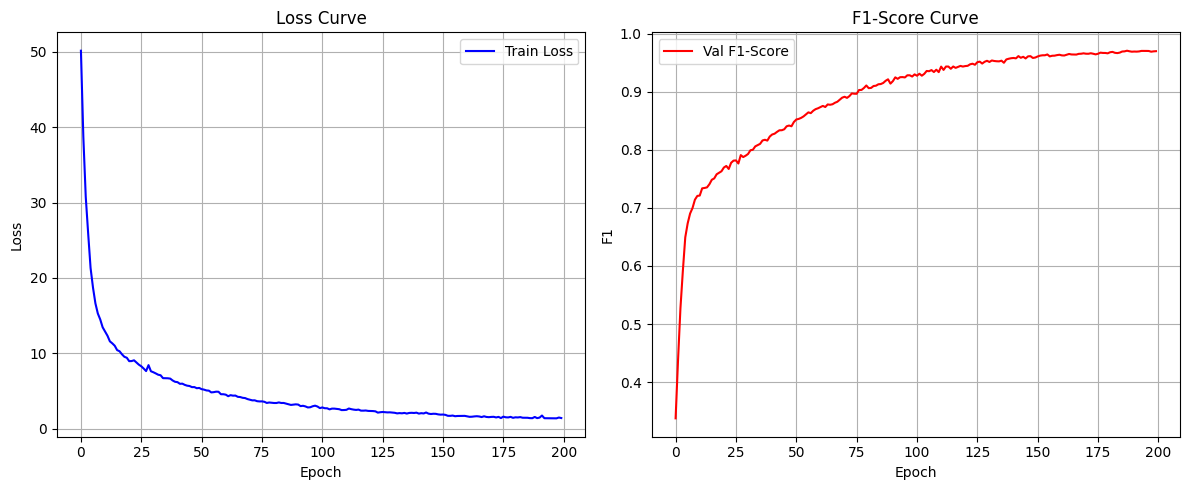

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torch.amp import autocast, GradScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")

train_csv = "/content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset.csv"
val_csv = "/content/drive/MyDrive/dental_dataset/reduced_final_combined_dataset_valid.csv"

df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

label_cols = [
    'Caries', 'Crown', 'Filling', 'Implant', 'Malaligned',
    'Mandibular_Canal', 'Missing_teeth', 'Periapical_lesion',
    'Retained_root', 'Root_Canal_Treatment', 'Root_Piece',
    'impacted_tooth', 'maxillary_sinus', 'Bone_Loss', 'Fracture_teeth',
    'Permanent_Teeth', 'Supra_Eruption', 'TAD', 'abutment', 'attrition',
    'bone_defect', 'gingival_former', 'metal_band', 'orthodontic_brackets',
    'permanent_retainer', 'post___core', 'plating', 'wire', 'Cyst',
    'Root_resorption', 'Primary_teeth'
]

cnn_cols = [col for col in df_train.columns if col.startswith('cnn_')]
manual_cols = ['mean_intensity', 'std_intensity', 'dark_pixel_count', 'symmetry_score', 'image_entropy']

df_train = df_train[cnn_cols + manual_cols + label_cols]
df_val = df_val[cnn_cols + manual_cols + label_cols]

X_cnn_train = df_train[cnn_cols].values.astype(np.float32)
X_manual_train = df_train[manual_cols].values.astype(np.float32)
y_train = df_train[label_cols].values.astype(np.float32)

X_cnn_val = df_val[cnn_cols].values.astype(np.float32)
X_manual_val = df_val[manual_cols].values.astype(np.float32)
y_val = df_val[label_cols].values.astype(np.float32)

non_zero_rows_train = y_train.sum(axis=1) > 0
X_cnn_train = X_cnn_train[non_zero_rows_train]
X_manual_train = X_manual_train[non_zero_rows_train]
y_train = y_train[non_zero_rows_train]

manual_scaler = StandardScaler()
X_train_manual = manual_scaler.fit_transform(X_manual_train)
X_val_manual = manual_scaler.transform(X_manual_val)

cnn_scaler = StandardScaler()
X_cnn_train_scaled = cnn_scaler.fit_transform(X_cnn_train)
X_cnn_val_scaled = cnn_scaler.transform(X_cnn_val)

pca = PCA(n_components=512)
X_cnn_train_pca = pca.fit_transform(X_cnn_train_scaled)
X_cnn_val_pca = pca.transform(X_cnn_val_scaled)

X_train = np.hstack([X_cnn_train_pca, X_train_manual])
X_val = np.hstack([X_cnn_val_pca, X_val_manual])

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)


class DentalClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.SiLU(),
            nn.LayerNorm(1024),
            nn.Dropout(0.6),

            nn.Linear(1024, 512),
            nn.SiLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.6),

            nn.Linear(512, len(label_cols))
        )

    def forward(self, x):
        return self.classifier(x)

model = DentalClassifier(input_dim=X_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scaler = GradScaler()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

def focal_loss(inputs, targets, gamma=2, alpha=0.25):
    bce_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
    probas = torch.sigmoid(inputs)
    loss = alpha * bce_loss * ((1 - probas) ** gamma)
    return loss.mean()

pos_weights = []
for i in range(len(label_cols)):
    neg = (y_train[:, i] == 0).sum()
    pos = (y_train[:, i] == 1).sum()
    if pos == 0:
        pos_weights.append(1.0)
    else:
        pos_weights.append(neg / (pos + 1e-6))

pos_weights_tensor = torch.tensor(pos_weights, device=device, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=200):
    best_val_f1 = 0.0
    patience_counter = 0
    PATIENCE_LIMIT = 20
    train_losses = []
    val_f1s = []

    print("[INFO] Starting training...")

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for inputs, labels_batch in train_loader:
            inputs = inputs.to(device).float()
            labels_batch = labels_batch.to(device).float()

            optimizer.zero_grad()

            noise = torch.randn_like(inputs) * 0.01
            inputs += noise
            if device == "cuda":
                with autocast(device_type="cuda"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels_batch)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

        model.eval()
        all_preds = []
        all_true = []

        with torch.no_grad():
            for inputs, labels_batch in val_loader:
                inputs = inputs.to(device).float()
                labels_batch = labels_batch.to(device).float()

                outputs = model(inputs)
                all_preds.append(torch.sigmoid(outputs).cpu())
                all_true.append(labels_batch.cpu())

        all_preds_np = torch.cat(all_preds).numpy()
        all_true_np = torch.cat(all_true).numpy()

        all_preds_binary = (all_preds_np > 0.5).astype(int)
        all_true_binary = (all_true_np > 0.5).astype(int)

        avg_f1 = f1_score(all_true_binary, all_preds_binary, average='samples')

        print(f"\n[Epoch {epoch+1}] Train Loss = {total_loss:.4f}, Val F1-Score = {avg_f1:.4f}")

        if avg_f1 > best_val_f1:
            best_val_f1 = avg_f1
            torch.save(model.state_dict(), "/content/drive/MyDrive/dental_dataset/best_dental_model.pt")
            patience_counter = 0
            print(" Best model saved.")
        else:
            patience_counter += 1
            print(f" No improvement. Patience: {patience_counter}/{PATIENCE_LIMIT}")

        # تحديث LR ← عند Plateau
        scheduler.step(avg_f1)
        train_losses.append(total_loss)
        val_f1s.append(avg_f1)

        if patience_counter >= PATIENCE_LIMIT and epoch > 50:
            print(" Training stopped early due to no improvement.")
            break

    return {
        'losses': train_losses,
        'f1_scores': val_f1s,
        'probs': all_preds_np,
        'labels': all_true_np
    }

results = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=200)



print("\n Plotting training curves...")

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(results['losses'], label="Train Loss", color="blue")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# F1-Score Curve
plt.subplot(1, 2, 2)
plt.plot(results['f1_scores'], label="Val F1-Score", color="red")
plt.title("F1-Score Curve")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score

model.load_state_dict(torch.load("/content/drive/MyDrive/dental_dataset/best_dental_model.pt"))
model.eval()

all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for inputs, labels_batch in val_loader:
        inputs = inputs.to(device)
        labels_batch = labels_batch.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.append(probs)
        all_preds.append((probs > 0.5).astype(int))
        all_true.append(labels_batch.cpu().numpy())

all_probs_np = np.vstack(all_probs)
all_preds_np = np.vstack(all_preds)
all_true_np = np.vstack(all_true)

print("\nالتقرير التفصيلي ")
print(classification_report(
    all_true_np,
    all_preds_np,
    target_names=label_cols,
    zero_division=0,
    digits=4
))

f1_scores = f1_score(all_true_np, all_preds_np, average=None, zero_division=0)
performance_categories = {
    "ممتاز (F1 > 0.9)": [],
    "جيد (0.7 < F1 ≤ 0.9)": [],
    "ضعيف (F1 ≤ 0.7)": []
}

for idx, score in enumerate(f1_scores):
    if score > 0.9:
        performance_categories["ممتاز (F1 > 0.9)"].append(label_cols[idx])
    elif score > 0.7:
        performance_categories["جيد (0.7 < F1 ≤ 0.9)"].append(label_cols[idx])
    else:
        performance_categories["ضعيف (F1 ≤ 0.7)"].append(label_cols[idx])

print("\n تصنيف الفئات حسب الأداء:")
for category, classes in performance_categories.items():
    print(f"\n{category}:")
    for cls in classes:
        print(f"- {cls}: {f1_scores[label_cols.index(cls)]:.4f}")

positive_counts = all_true_np.sum(axis=0)
rare_classes_info = []

for i, count in enumerate(positive_counts):
    if count < 15:
        rare_classes_info.append({
            "الفئة": label_cols[i],
            "عدد العينات": int(count),
            "F1-Score": f1_scores[i]
        })

if rare_classes_info:
    print("\n الفئات النادرة (عدد العينات < 15):")
    display(pd.DataFrame(rare_classes_info).sort_values("عدد العينات"))
else:
    print("\n لا توجد فئات نادرة (جميعها لديها ≥ 15 عينة)")

try:
    overall_f1 = f1_score(all_true_np, all_preds_np, average='samples')
    overall_precision = precision_score(all_true_np, all_preds_np, average='samples', zero_division=0)
    overall_recall = recall_score(all_true_np, all_preds_np, average='samples', zero_division=0)


    print(f"- F1-Score (Samples): {overall_f1:.4f}")
    print(f"- Precision: {overall_precision:.4f}")
    print(f"- Recall: {overall_recall:.4f}")
except Exception as e:
    print(f"\n خطأ في حساب المقاييس: {str(e)}")


error_rates = []
for i in range(len(label_cols)):
    incorrect = np.sum((all_preds_np[:, i] != all_true_np[:, i]) & (all_true_np[:, i] == 1))
    total = np.sum(all_true_np[:, i])
    error_rate = incorrect / total if total > 0 else 0
    error_rates.append({
        "الفئة": label_cols[i],
        "نسبة الخطأ": f"{error_rate:.2%}",
        "عدد الأخطاء": int(incorrect),
        "إجمالي العينات": int(total)
    })

print("\n تحليل الأخطاء (للعينات الإيجابية فقط):")
display(pd.DataFrame(error_rates).sort_values("نسبة الخطأ", ascending=False))


التقرير التفصيلي 
                      precision    recall  f1-score   support

              Caries     0.9951    1.0000    0.9976       614
               Crown     0.9720    1.0000    0.9858       797
             Filling     0.9908    0.9482    0.9690      2046
             Implant     1.0000    1.0000    1.0000       109
          Malaligned     1.0000    1.0000    1.0000         4
    Mandibular_Canal     0.9500    1.0000    0.9744        38
       Missing_teeth     0.9885    1.0000    0.9942       257
   Periapical_lesion     0.9515    1.0000    0.9752       471
       Retained_root     1.0000    1.0000    1.0000         2
Root_Canal_Treatment     0.9934    0.9991    0.9962      1061
          Root_Piece     0.9427    1.0000    0.9705       181
      impacted_tooth     0.9970    0.9623    0.9794      2416
     maxillary_sinus     1.0000    1.0000    1.0000        27
           Bone_Loss     0.7114    1.0000    0.8314       212
      Fracture_teeth     0.5000    1.0000    0.666

,الفئة,عدد العينات,F1-Score
3,Permanent_Teeth,0,0.000000
5,TAD,0,0.000000
7,attrition,0,0.000000
8,bone_defect,0,0.000000
12,permanent_retainer,0,0.000000
13,plating,0,0.000000
16,Root_resorption,0,0.000000
10,metal_band,1,0.666667
15,Cyst,1,0.666667
1,Retained_root,2,1.000000


- F1-Score (Samples): 0.9705
- Precision: 0.9760
- Recall: 0.9743

 تحليل الأخطاء (للعينات الإيجابية فقط):


,الفئة,نسبة الخطأ,عدد الأخطاء,إجمالي العينات
2,Filling,5.18%,106,2046
11,impacted_tooth,3.77%,91,2416
9,Root_Canal_Treatment,0.09%,1,1061
0,Caries,0.00%,0,614
19,attrition,0.00%,0,0
20,bone_defect,0.00%,0,0
21,gingival_former,0.00%,0,2
22,metal_band,0.00%,0,1
23,orthodontic_brackets,0.00%,0,9
24,permanent_retainer,0.00%,0,0


[INFO] Model loaded successfully.


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0



Lesions Detected:
- Caries: 0.81
- Filling: 0.93
- Implant: 0.55
- impacted_tooth: 0.69
- Bone_Loss: 1.00
- Fracture_teeth: 0.52
- abutment: 1.00


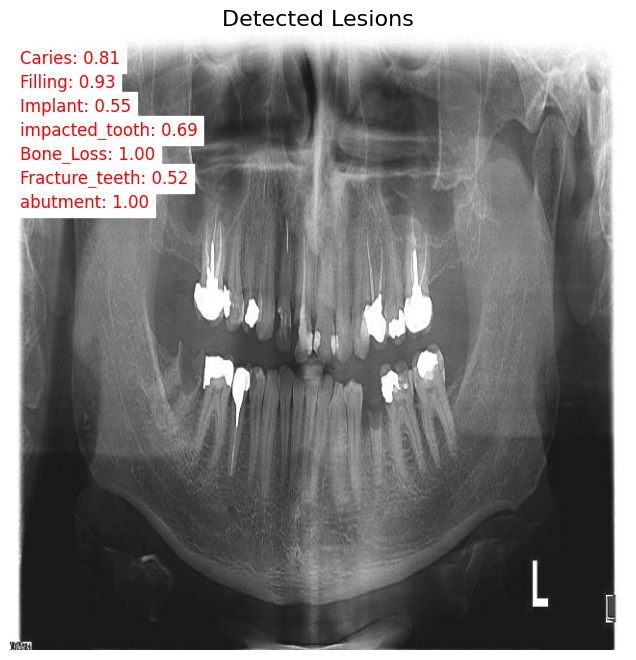

In [ ]:
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn
import os
import matplotlib.pyplot as plt

label_cols = [
    'Caries', 'Crown', 'Filling', 'Implant', 'Malaligned',
    'Mandibular_Canal', 'Missing_teeth', 'Periapical_lesion',
    'Retained_root', 'Root_Canal_Treatment', 'Root_Piece',
    'impacted_tooth', 'maxillary_sinus', 'Bone_Loss', 'Fracture_teeth',
    'Permanent_Teeth', 'Supra_Eruption', 'TAD', 'abutment', 'attrition',
    'bone_defect', 'gingival_former', 'metal_band', 'orthodontic_brackets',
    'permanent_retainer', 'post___core', 'plating', 'wire', 'Cyst',
    'Root_resorption', 'Primary_teeth'
]

model_path = "/content/drive/MyDrive/dental_dataset/best_dental_model.pt"
image_path = "/content/drive/MyDrive/dental_dataset/dental_dataset/images/test/000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.f00e39f32edbca5c4cf42f39d9b0364c.jpg"

class DentalClassifier(nn.Module):
    def __init__(self, input_dim=517, num_classes=31):
        super(DentalClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.SiLU(),
            nn.LayerNorm(1024),
            nn.Dropout(0.6),

            nn.Linear(1024, 512),
            nn.SiLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.6),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

def extract_cnn_features(image_path, device):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    feature_extractor.eval().to(device)

    with torch.no_grad():
        features = feature_extractor(image_tensor).squeeze().cpu().numpy()

    return features.astype(np.float32)

def extract_manual_features(image_path):
    image = Image.open(image_path).convert("L")
    img_array = np.array(image).astype(np.float32) / 255.0

    mean_intensity = np.mean(img_array)
    std_intensity = np.std(img_array)
    dark_pixel_count = (img_array < 0.3).sum()
    symmetry_score = np.mean(img_array[:, :img_array.shape[1]//2] - img_array[:, img_array.shape[1]//2:])
    image_entropy = -np.sum(img_array * np.log(img_array + 1e-8))

    manual_features = np.array([
        mean_intensity,
        std_intensity,
        dark_pixel_count,
        symmetry_score,
        image_entropy
    ], dtype=np.float32)

    return manual_features
def mock_pca_and_scaler(cnn_features, manual_features):
    mock_pca_weights = np.random.randn(512, 2048) * 0.1
    cnn_pca = (mock_pca_weights @ cnn_features.T).T

    mock_mean = np.zeros(512)
    mock_std = np.ones(512)
    cnn_scaled = (cnn_pca - mock_mean) / (mock_std + 1e-6)

    manual_mean = np.zeros(5)
    manual_std = np.ones(5)
    manual_scaled = (manual_features - manual_mean) / (manual_std + 1e-6)

    final_features = np.hstack([cnn_scaled, manual_scaled])
    return final_features

def predict_image(image_path, model, label_cols, device):
    cnn_features = extract_cnn_features(image_path, device)
    manual_features = extract_manual_features(image_path)
    combined_features = mock_pca_and_scaler(cnn_features, manual_features)

    features_tensor = torch.tensor(combined_features, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(features_tensor)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()

    detected = [(label_cols[i], probs[i]) for i, p in enumerate(probs) if p > 0.5]
    return probs, detected

# عرض الصورة مع النتائج
def display_image_with_predictions(image_path, detected_lesions):
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis('off')

    for idx, (label, prob) in enumerate(detected_lesions):
        plt.text(
            10, 30 + idx * 25,
            f"{label}: {prob:.2f}",
            fontsize=12,
            color='red',
            backgroundcolor='white'
        )

    plt.title("Detected Lesions", fontsize=16)
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    model = DentalClassifier(input_dim=517)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    print("[INFO] Model loaded successfully.")
except FileNotFoundError:
    print(f"[ERROR] Model file not found at {model_path}")
    exit()

try:
    probs, lesions = predict_image(image_path, model, label_cols, device)

    print("\nLesions Detected:")
    if lesions:
        for lesion, prob in lesions:
            print(f"- {lesion}: {prob:.2f}")
        display_image_with_predictions(image_path, lesions)
    else:
        print("No lesions detected.")
except FileNotFoundError:
    print(f"[ERROR] Image not found at {image_path}")
except Exception as e:
    print(f"[ERROR] An error occurred: {e}")


In [ ]:

import os
import json
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from torch.optim.lr_scheduler import OneCycleLR
from google.colab import drive
from sklearn.metrics import f1_score
import numpy as np
from torch.amp import autocast, GradScaler
import time
import sys

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

drive.mount('/content/drive', force_remount=True)


class DentalDataset(Dataset):
    def __init__(self, json_path, image_dirs, transforms=None):
        with open(json_path, 'r') as f:
            self.coco = json.load(f)
        self.transforms = transforms
        self.image_dirs = image_dirs if isinstance(image_dirs, list) else [image_dirs]

        self.filename_to_path = {}
        for img_dir in self.image_dirs:
            if not os.path.exists(img_dir):
                continue
            for root, _, files in os.walk(img_dir):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                        key = file.lower()
                        if key not in self.filename_to_path:
                            self.filename_to_path[key] = os.path.join(root, file)

        self.img_id_to_name = {img['id']: img['file_name'] for img in self.coco['images']}
        self.annotations_per_image = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.annotations_per_image:
                self.annotations_per_image[img_id] = []
            self.annotations_per_image[img_id].append(ann)

        self.valid_images = {}
        for img in self.coco['images']:
            filename = img['file_name']
            if filename.lower() in self.filename_to_path:
                self.valid_images[img['id']] = {'filename': filename, 'path': self.filename_to_path[filename.lower()]}

        self.category_mapping = {cat['id']: cat['name'] for cat in self.coco['categories']}
        sorted_ids = sorted(self.category_mapping.keys())
        self.id_to_continuous = {old_id: i for i, old_id in enumerate(sorted_ids)}
        self.continuous_to_original = {i: old_id for i, old_id in enumerate(sorted_ids)}
        self.num_classes = len(self.category_mapping)

        print(f"[INFO] Loaded {len(self.valid_images)} images")
        print(f"[INFO] Number of classes: {self.num_classes}")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_id = list(self.valid_images.keys())[idx]
        info = self.valid_images[img_id]
        image = Image.open(info['path']).convert("RGB")

        boxes = []
        labels = []
        for ann in self.annotations_per_image.get(img_id, []):
            x_min, y_min, w, h = ann['bbox']
            boxes.append([x_min, y_min, x_min + w, y_min + h])
            labels.append(self.id_to_continuous[ann['category_id']])

        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor(img_id)}

        if self.transforms:
            image = self.transforms(image)

        return image, target

def get_transform(train=True):
    transforms = [T.Resize((640, 640))]
    if train: transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.extend([T.ToTensor(), T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])
    return T.Compose(transforms)


train_json = "/content/drive/MyDrive/dental_dataset/annotations/train_coco_fixed.json"
val_json   = "/content/drive/MyDrive/dental_dataset/annotations/valid_coco_fixed.json"
image_dirs = [
    "/content/drive/MyDrive/dental_dataset/images/train",
    "/content/drive/MyDrive/dental_dataset/images/valid",
    "/content/drive/MyDrive/dental_dataset/images/test"
]


def check_gpu():
    print("=== GPU Status Check ===")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"GPU: {gpu_name} | Memory: {gpu_mem:.1f} GB")
        device = torch.device("cuda")
    else:
        print(" No GPU available! Enable GPU in Colab")
        device = torch.device("cpu")
    return device

device = check_gpu()

dataset_train = DentalDataset(train_json, image_dirs, transforms=get_transform(True))
dataset_val   = DentalDataset(val_json, image_dirs, transforms=get_transform(False))

data_loader_train = DataLoader(dataset_train, batch_size=6, shuffle=True, collate_fn=lambda x: tuple(zip(*x)), num_workers=2, pin_memory=device.type=='cuda', persistent_workers=True, prefetch_factor=2)
data_loader_val   = DataLoader(dataset_val, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)), num_workers=2, pin_memory=device.type=='cuda')

print(f"[INFO] Training on {len(dataset_train)} images")
print(f"[INFO] Validation on {len(dataset_val)} images")
print(f"[INFO] Using device: {device}")


def get_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=3)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(dataset_train.num_classes).to(device)


def compute_f1_score(targets, outputs, num_classes, threshold=0.5):
    y_true, y_pred = [], []
    for target, out in zip(targets, outputs):
        gt_labels = target['labels'].cpu().numpy()
        true_bin = np.zeros(num_classes)
        for l in gt_labels: true_bin[l]=1

        if len(out['boxes'])>0 and 'scores' in out:
            scores = out['scores'].cpu().numpy()
            pred_labels = out['labels'].cpu().numpy()
            pred_bin = np.zeros(num_classes)
            for l,s in zip(pred_labels,scores):
                if s>threshold: pred_bin[l]=1
        else: pred_bin = np.zeros(num_classes)

        y_true.append(true_bin)
        y_pred.append(pred_bin)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if y_true.sum()==0 and y_pred.sum()==0: return 1.0
    elif y_true.sum()==0 or y_pred.sum()==0: return 0.0
    return f1_score(y_true, y_pred, average='samples')


params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=2e-4, weight_decay=0.05)
scheduler = OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(data_loader_train), epochs=25, pct_start=0.1, anneal_strategy='cos')
scaler = GradScaler(device="cuda")

best_val_f1 = 0.0
patience = 8
patience_counter = 0
eval_every_n_epochs = 2

checkpoint_path = "/content/drive/MyDrive/dental_dataset/checkpoint.pth"
start_epoch = 0


if os.path.exists(checkpoint_path):
    print("[INFO] Found checkpoint, loading...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    best_val_f1 = checkpoint.get('best_val_f1', 0.0)
    start_epoch = checkpoint.get('epoch', 0) + 1
    print(f"[INFO] Resuming training from epoch {start_epoch} | Best Val F1: {best_val_f1:.4f}")
else:
    print("[INFO] No checkpoint found, starting fresh training")

print(f"\n[INFO] Starting training on {device} with Mixed Precision")
start_time = time.time()

for epoch in range(start_epoch, 25):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()
    print(f"\n===== Epoch {epoch+1}/25 =====")
    for batch_idx, (images, targets) in enumerate(data_loader_train,1):
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += losses.item()

        if batch_idx%10==0 or batch_idx==len(data_loader_train):
            avg_loss = epoch_loss/batch_idx
            progress = 100*batch_idx/len(data_loader_train)
            elapsed = time.time()-epoch_start
            est_total = elapsed/batch_idx*len(data_loader_train)
            est_remain = est_total-elapsed
            sys.stdout.write(f"\rEpoch {epoch+1} | [{batch_idx}/{len(data_loader_train)} - {progress:.1f}%] Loss(avg): {avg_loss:.4f} | Elapsed: {elapsed/60:.1f}m | ETA: {est_remain/60:.1f}m")
            sys.stdout.flush()
    print()

    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_f1': best_val_f1,
        'epoch': epoch,
        'class_mapping': dataset_train.category_mapping,
        'continuous_mapping': dataset_train.continuous_to_original,
        'pytorch_version': torch.__version__
    }, checkpoint_path)
    print(f" Checkpoint saved at epoch {epoch+1}")

    epoch_time = time.time()-epoch_start
    avg_loss = epoch_loss/len(data_loader_train)
    print(f"  Epoch {epoch+1} completed in {epoch_time/60:.1f} minutes | Avg Loss: {avg_loss:.4f}")

    if (epoch+1)%eval_every_n_epochs==0:
        model.eval()
        all_targets, all_outputs = [], []
        with torch.no_grad():
            for images, targets in data_loader_val:
                images = [img.to(device) for img in images]
                outputs = model(images)
                all_targets.extend(targets)
                all_outputs.extend(outputs)

        val_f1 = compute_f1_score(all_targets, all_outputs, dataset_train.num_classes)
        print(f" Epoch {epoch+1}/25 | Val F1: {val_f1:.4f}")

        if val_f1>best_val_f1:
            best_val_f1 = val_f1
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1,
                'epoch': epoch,
                'class_mapping': dataset_train.category_mapping,
                'continuous_mapping': dataset_train.continuous_to_original,
                'pytorch_version': torch.__version__
            }, "/content/drive/MyDrive/dental_dataset/complete_model.pth")
            print("💾 Best model saved with metadata")
            patience_counter=0
        else:
            patience_counter+=1
            print(f" No improvement: {patience_counter}/{patience}")
        if patience_counter>=patience:
            print(" Early stopping triggered")
            break

total_time = time.time()-start_time
print(f"\n Training completed in {total_time/3600:.1f} hours | Best Val F1: {best_val_f1:.4f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/dental_dataset/final_model_weights.pth")
print(" Final model weights saved")
